In [ ]:
# ANN

from keras.datasets import mnist


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from keras import backend as K
from tensorflow.keras.utils import to_categorical
from  matplotlib import pyplot as plt


In [ ]:
# split data into train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape,y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,)


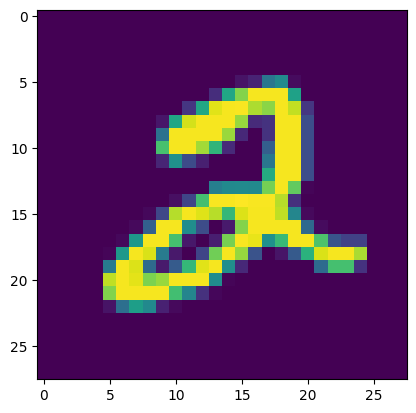

In [ ]:
plt.imshow(x_train[5])

In [ ]:
# we want to transform our dataset from having shape (n, width, height) to (n,width)
#(height,depth)
x_train = x_train.reshape(x_train.shape[0],28,28,1)
x_test = x_test.reshape(x_test.shape[0],28,28,1)
input_shape = (28,28,1)

In [ ]:
print(x_train.shape,x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [ ]:
# the preprocessing step for the input data is to convert our data type to float32 and normalize our data values to the range [0,1]
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /=255
x_test /=255

In [ ]:
print(y_train.shape)

(60000, 10)


In [ ]:
batch_size = 126
epocha = 5
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3),activation='relu',input_shape=input_shape))
model.add(Conv2D(64, (3, 3), activation ='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
import keras
model.compile(loss=keras.losses.categorical_crossentropy,optimizer=Adam(), metrics=['accuracy'])

In [ ]:
# fit data to model

hist = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1, validation_data=(x_test, y_test))
print("The  model has successfully trained")
# saving model
model.save('mnist.h5')
print("Saving the model mnist.h5")

Epoch 1/5
477/477 ━━━━━━━━━━━━━━━━━━━━ 176s 365ms/step - accuracy: 0.6892 - loss: 0.9630 - val_accuracy: 0.9091 - val_loss: 0.3067
Epoch 2/5
477/477 ━━━━━━━━━━━━━━━━━━━━ 166s 348ms/step - accuracy: 0.8837 - loss: 0.3843 - val_accuracy: 0.9317 - val_loss: 0.2265
Epoch 3/5
477/477 ━━━━━━━━━━━━━━━━━━━━ 210s 364ms/step - accuracy: 0.9027 - loss: 0.3234 - val_accuracy: 0.9432 - val_loss: 0.1850
Epoch 4/5
477/477 ━━━━━━━━━━━━━━━━━━━━ 200s 361ms/step - accuracy: 0.9121 - loss: 0.2920 - val_accuracy: 0.9487 - val_loss: 0.1594
Epoch 5/5
477/477 ━━━━━━━━━━━━━━━━━━━━ 199s 354ms/step - accuracy: 0.9202 - loss: 0.2672 - val_accuracy: 0.9558 - val_loss: 0.1445


The  model has successfully trained
Saving the model mnist.h5


In [ ]:
# evalued model
score = model.evaluate(x_test,y_test,verbose=0)
print('Test loss:',score[0])
print('Test accuracy:',score[1])

Test loss: 0.14446863532066345
Test accuracy: 0.9557999968528748


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


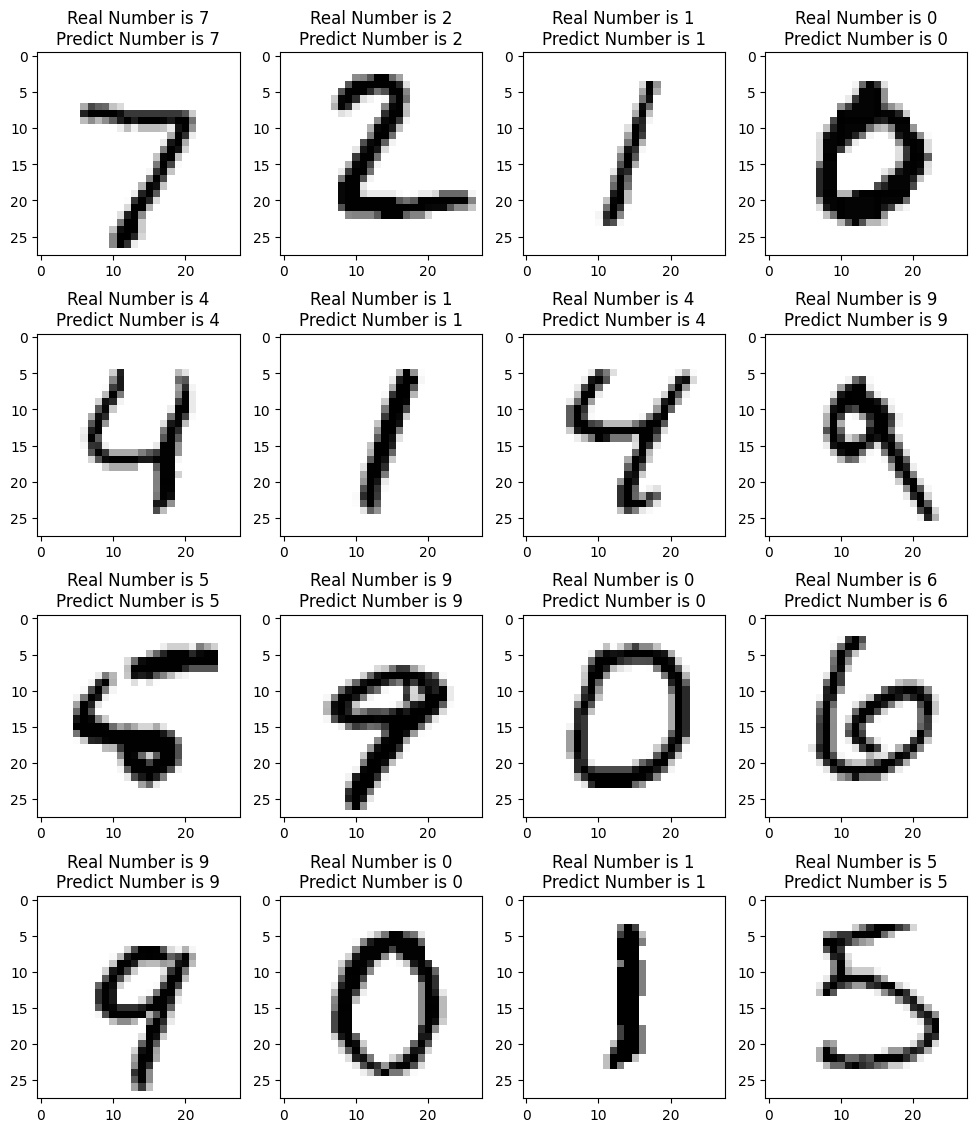

In [ ]:
y_pred = model.predict(x_test)
X_test__ = x_test.reshape(x_test.shape[0], 28, 28)
fig, axis = plt.subplots(4, 4, figsize=(12, 14))
for i, ax in enumerate(axis.flat):
    ax.imshow(X_test__[i], cmap='binary')
    ax.set(title = f"Real Number is {y_test[i].argmax()}\nPredict Number is {y_pred[i].argmax()}");